In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mat_1 = np.ones((5, 5))

# Exercise 4

# perform slicing
mat_1[1:4, 1:4] = 0
print(mat_1)

# task 2
np.random.seed(42)
random_data = np.random.randn(100, 3)

# print(random_data)
normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print(normalized)

# task 3
X = np.random.randn(50, 3)

true_theta = np.array([2.5, -1.2, 3.7])

y = X @ true_theta + np.random.randn(50) * 0.1

# Normal equation
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("\nTask 3:")
print("Estimated coefficients:")
print(theta_hat)

print("\nTrue coefficients:")
print(true_theta)



[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818

In [87]:
# Exercise 5
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""


# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# task 1

# display basic information about the dataset
print(df.describe()) 

# identify and count missing values
df.isnull().sum()

# fill missing exam_score with the mean score for the student's major
df['exam_score'] = df['exam_score'].fillna(
    df.groupby('major')['exam_score'].transform('mean')
)

# fill missing hours_studied with the median for the student's year
df['hours_studied'] = df['hours_studied'].fillna(
    df.groupby('year')['hours_studied'].transform('median'))

print()

# task 2

# calculate and display the average exam_score by major
avg_table = df.groupby('major')['exam_score'].agg(['mean']).rename(columns={'mean': 'average'})
print(avg_table)

# find the major with the highest average exam_score
avg_by_major = df.groupby('major')['exam_score'].mean()

print()

top_major = avg_by_major.idxmax()
top_score = avg_by_major.max()

print("Top Major:", top_major)
print(f"Average Score: {top_score:.2f}")

print()

# calculate the correlation between hours_studied and exam_score
corrl = df['hours_studied'].corr(df['exam_score'])
print(f"The correlation between hours_studied and exam_score: {corrl}")

col_category = [df['exam_score'] > 90,
    (df['exam_score'] >= 80) & (df['exam_score'] <= 90),
    (df['exam_score'] >= 70) & (df['exam_score'] < 80),
    df['exam_score'] < 70
]

choices = ['Excellent', 'Good', 'Average', 'Needs Improvement']

df['performance'] = np.select(col_category, choices, default ='Unknown')

print()

# task 3
summary = df.groupby(['major', 'year']).agg(
    number_of_students=('student_id', 'count'),
    average_exam_score=('exam_score', 'mean'),
    average_hours_studied=('hours_studied', 'mean')
)

print(summary)

# identify top 5 students based on exam_score (handle ties appropriately) 
top_score_threshold = df['exam_score'].nlargest(5).min()

top_students = df[df['exam_score'] >= top_score_threshold]

print(top_students)

print()

# create a pivot table showing average exam_score by major (rows) and year (columns)
pivot = df.pivot_table(
    values = 'exam_score',
    index = 'major',
    columns = 'year',
    aggfunc = 'mean'
)

print(pivot)


        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000000   
50%    1099.500000    3.000000   75.728033               4.000000   
75%    1149.250000    4.000000   81.813642               8.000000   
max    1199.000000    4.000000  100.000000              10.000000   

       hours_studied  
count     195.000000  
mean       14.776761  
std         5.251905  
min         1.295226  
25%        11.637963  
50%        14.575456  
75%        18.345691  
max        28.918887  

           average
major             
Biology  75.503150
CS       76.425184
Math     74.683689
Physics  75.406509

Top Major: CS
Average Score: 76.43

The correlation bet

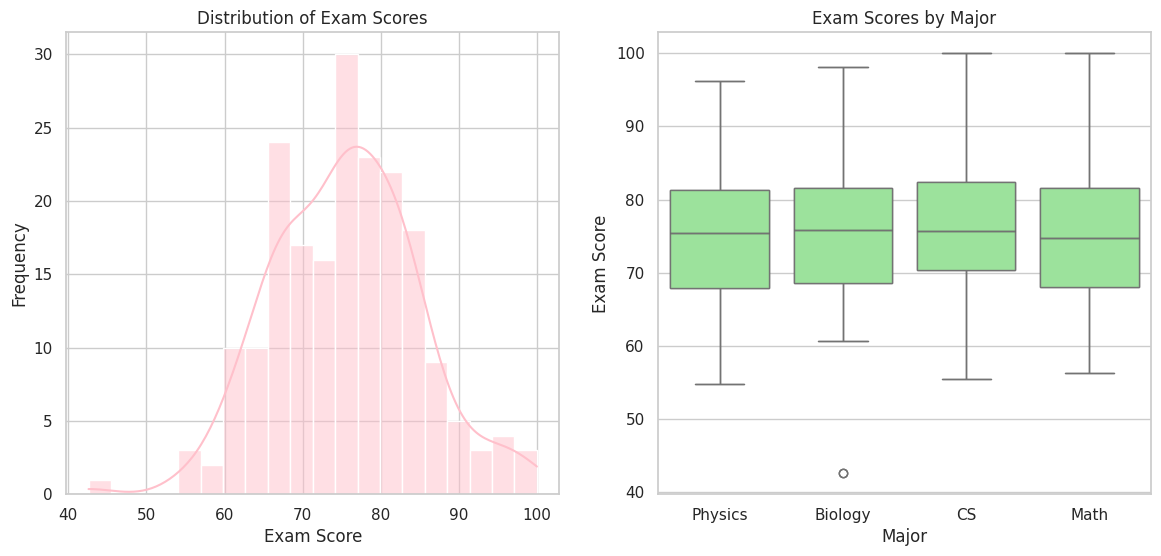

<Figure size 1000x600 with 0 Axes>

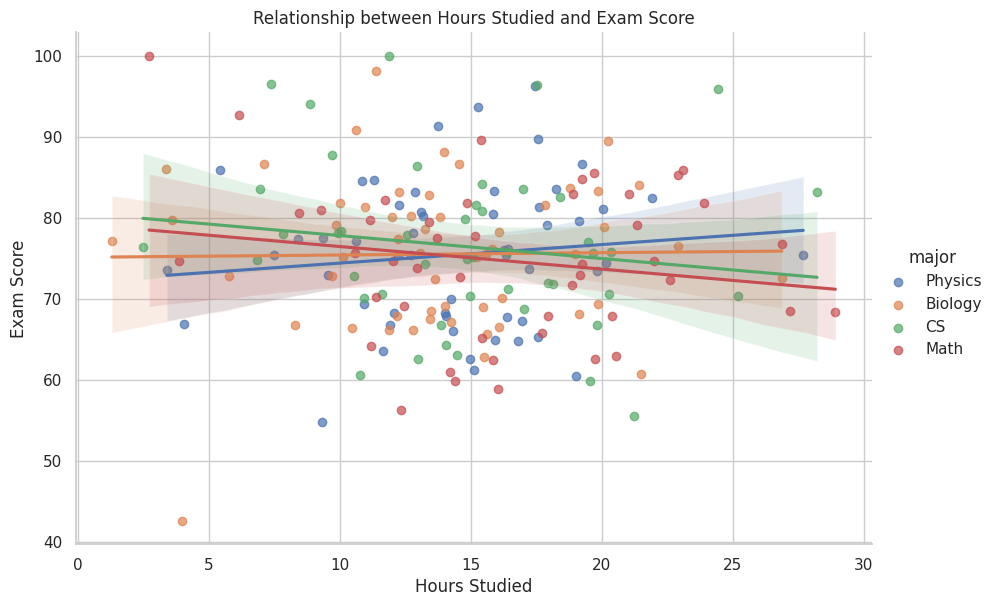

/tmp/ipykernel_28171/3102968953.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='year', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_28171/3102968953.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


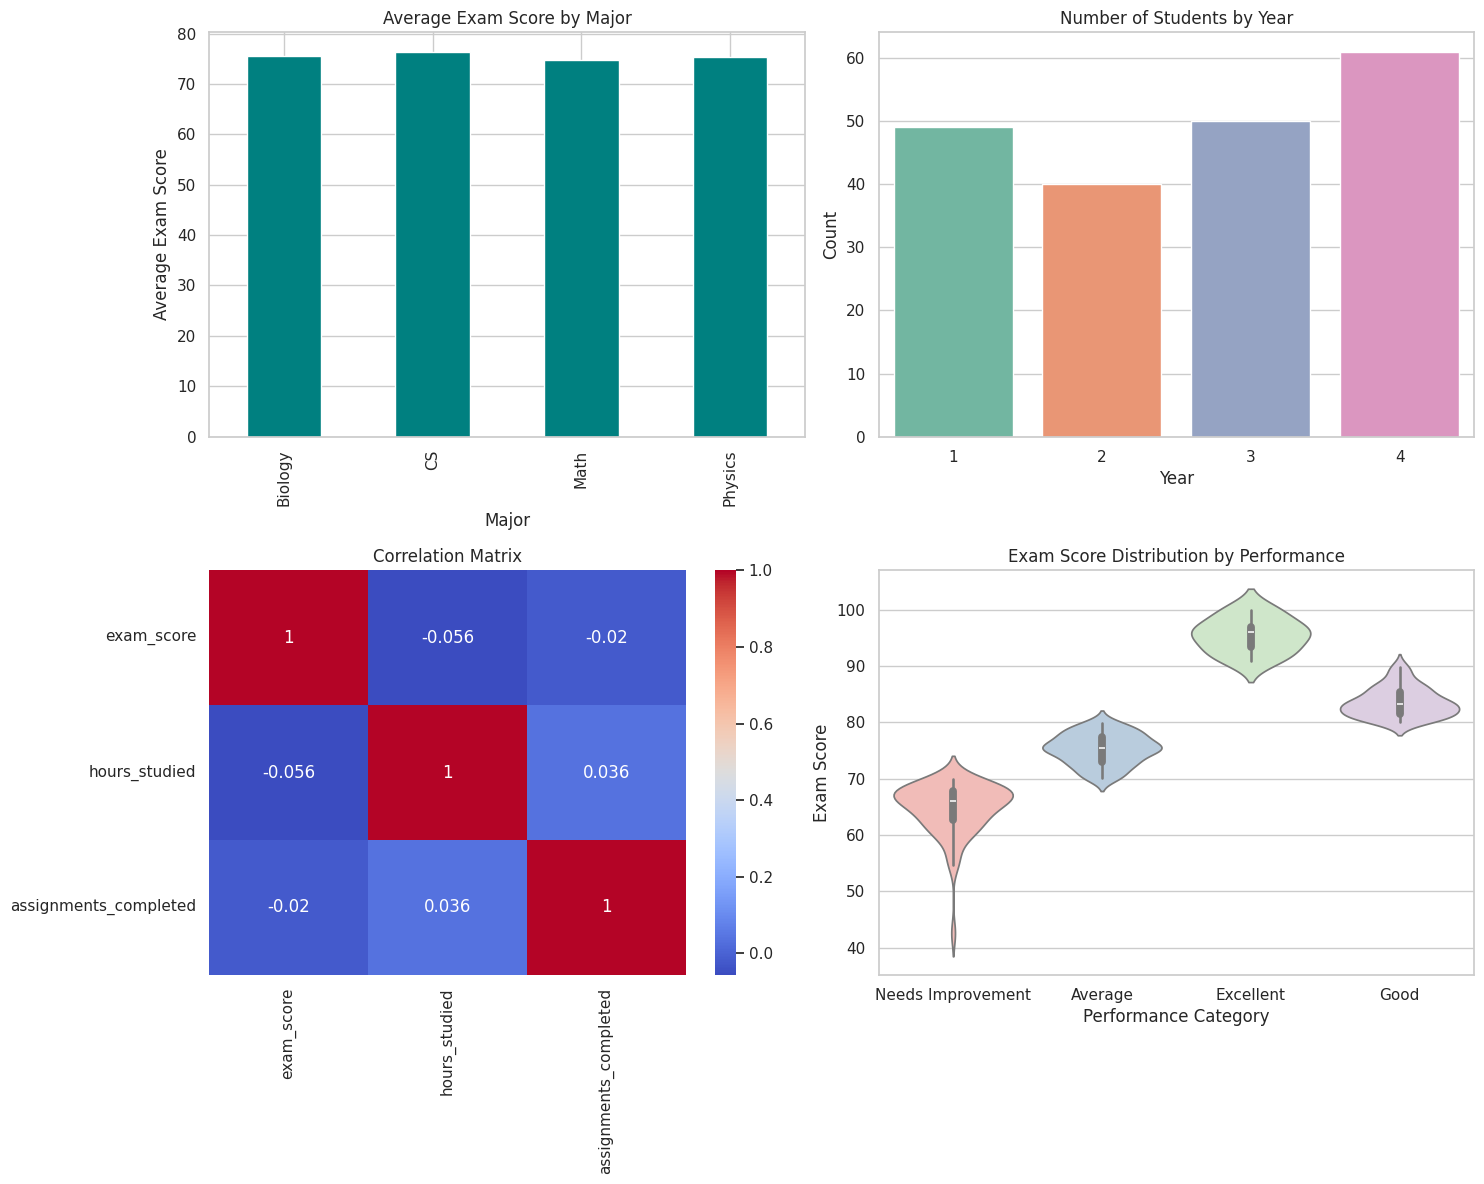

In [88]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

# task 1

# create a figure with 2 subplots side by side
# plt.figure(figsize=(14,6))

plt.figure(figsize=(14,6))


plt.subplot(1, 2, 1)
sns.histplot(df['exam_score'], kde=True, bins=20, color='pink') # type: ignore

plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(x='major', y='exam_score', data=df, color="blue")

plt.title('Exam Scores by Major')
plt.xlabel('Major')
plt.ylabel('Exam Score')
plt.subplot(1, 2, 2)
sns.boxplot(x='major', y='exam_score', data=df, color="lightgreen")

plt.title('Exam Scores by Major')
plt.xlabel('Major')
plt.ylabel('Exam Score')

# task 2

plt.figure(figsize=(10, 6))

sns.set_theme(style="whitegrid")

# Scatter plot with regression line + color by major
sns.lmplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha': 0.7}
)

plt.title('Relationship between Hours Studied and Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')

plt.show()

# task 3

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))


# 1. Bar chart: Avg exam score by major
avg_major = df.groupby('major')['exam_score'].mean()

avg_major.plot(kind='bar', ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Exam Score')

# 2. Count plot: Students by year
sns.countplot(data=df, x='year', ax=axes[0, 1], palette='Set2')

axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

# 3. Heatmap: Correlation matrix
corr = df[['exam_score', 'hours_studied', 'assignments_completed']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1, 0])

axes[1, 0].set_title('Correlation Matrix')

# 4. Violin plot: Exam score by performance
sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1, 1],
    palette='Pastel1'
)

axes[1, 1].set_title('Exam Score Distribution by Performance')
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')

# Final layout adjustments
plt.tight_layout()
plt.show()


/tmp/ipykernel_28171/3448500020.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = df.groupby('age_group').agg(


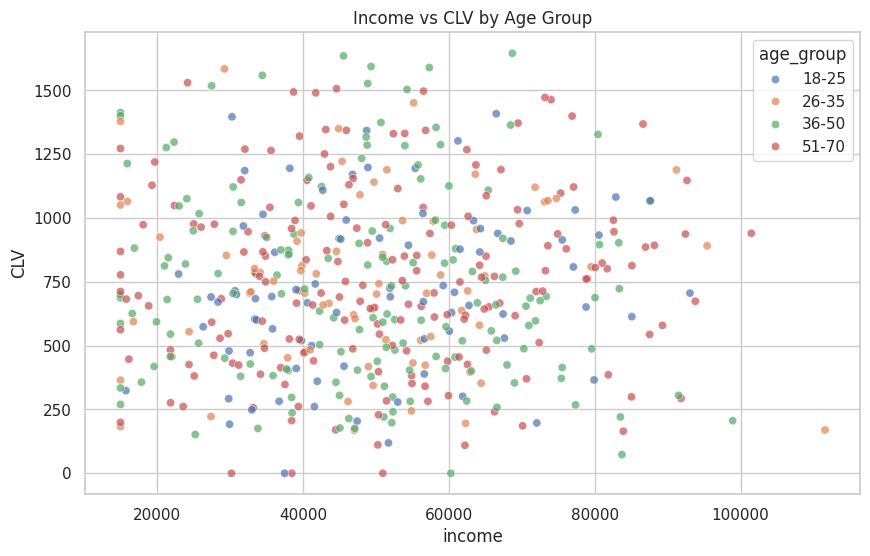

/tmp/ipykernel_28171/3448500020.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv = df.groupby('age_group')['CLV'].mean().sort_values()
/tmp/ipykernel_28171/3448500020.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_clv.index, y=avg_clv.values, palette='viridis')


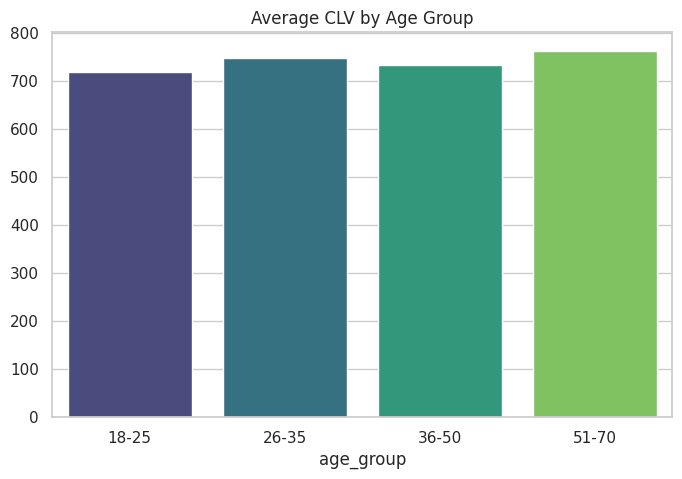

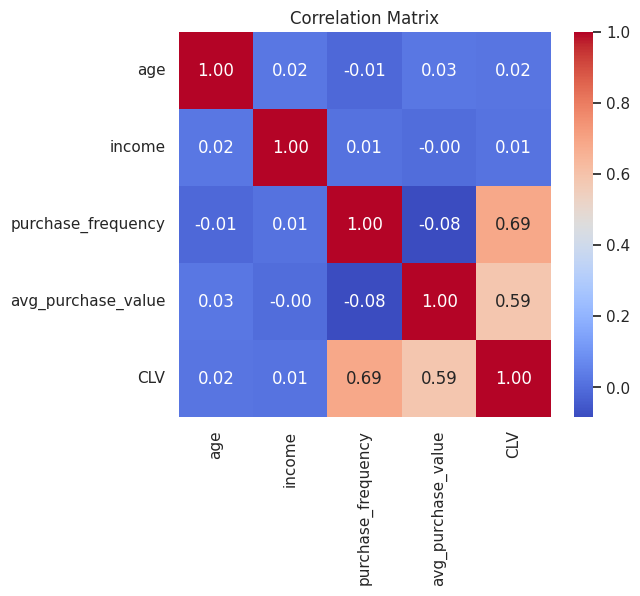

In [89]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})


# compute CLV
df = customers.copy()

max_freq = df['purchase_frequency'].max()

df['churn_risk'] = 1 - (df['purchase_frequency'] / max_freq)

df['CLV'] = df['purchase_frequency'] * df['avg_purchase_value'] * (1 + df['churn_risk'])


# Age Group
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'],
    include_lowest=True
)


# Age summary
age_summary = df.groupby('age_group').agg(
    customer_count=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_clv=('CLV', 'mean'),
    total_clv=('CLV', 'sum')
)


# Top 10% customers by CLV
threshold = df['CLV'].quantile(0.90)

top_customers = df[df['CLV'] >= threshold]


plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='income',
    y='CLV',
    hue='age_group',
    alpha=0.7
)

plt.title('Income vs CLV by Age Group')
plt.show()


# Average CLV by  Age group

avg_clv = df.groupby('age_group')['CLV'].mean().sort_values()

plt.figure(figsize=(8,5))

sns.barplot(x=avg_clv.index, y=avg_clv.values, palette='viridis')

plt.title('Average CLV by Age Group')
plt.show()


# Correlation HeatMap
plt.figure(figsize=(6,5))

sns.heatmap(df[['age','income','purchase_frequency','avg_purchase_value','CLV']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

The analysis shows that Customer lifetime value depends mostly on how often people buy and how much they spend each time. Customers who shop repeatedly bring in much more money over time. People aged 26 to 50 spend the most, so they’re the most valuable group. Higher income also leads to higher spending. A small group, just the top 10% of customers, makes up a huge share of total sales. Because of this, keeping those key customers happy matters a lot. Focus on repeat buying and strong customer relationships instead of only chasing new customers.